# 📐 nb04 — Ukur Reranking dengan RAGAS

## Tujuan

**nb03** *menunjukkan* bahwa reranker menggeser passage off-topic keluar dari top-3 secara visual.  
**nb04** *membuktikannya* dengan **angka** — menggunakan framework evaluasi RAGAS.

> **Tanpa ukur = menebak.**

### Eksperimen

| Komponen | Nilai |
|---|---|
| Korpus | 12 passage employee handbook (sama seperti nb03) |
| Pertanyaan | 7 pertanyaan tes (+ *reference* / jawaban benar) |
| Generator | Qwen2.5-3B-Instruct 4-bit **LOKAL** di T4 |
| Judge | Nemotron-3-Super-120B (default) / Llama-3.3-70B (fallback) via NVIDIA NIM **CLOUD** (gratis) |

Satu-satunya yang berubah antara Varian A dan B adalah `retrieved_contexts`:
- **Varian A**: bi-encoder top-3 (tanpa rerank)
- **Varian B**: bi-encoder top-12 → CrossEncoder rerank → top-3

Inti filosofi: **judge = model cloud** (0 VRAM T4), **generator = Qwen lokal** (di T4).

## 4 Metrik RAGAS (Panduan Pemula)

Empat metrik yang kita pakai — dijelaskan tanpa rumus:

1. **Faithfulness** — seberapa banyak pernyataan dalam jawaban *bersandar* pada konteks yang diberikan (anti-halusinasi). Kalau model "ngarang", skor ini jatuh.
2. **Response Relevancy** — seberapa *nyambung* jawaban dengan pertanyaan asal (diukur pakai embedding cosine similarity). Jawaban bertele-tele atau melenceng = skor rendah.
3. **Context Precision** — proporsi potongan (*passage*) yang di-retrieve yang *benar-benar relevan*, dan apakah passage relevan ada di **posisi atas**. Inilah metrik yang paling langsung diperbaiki oleh reranker.
4. **Context Recall** — apakah semua potongan yang *diperlukan untuk menjawab* berhasil ter-retrieve. Kalau passage kunci tidak masuk top-k sama sekali, recall rendah.

### Tabel Dependensi Metrik

| Metrik | Butuh judge LLM? | Butuh embedding? | Butuh `reference` (jawaban benar)? |
|---|:---:|:---:|:---:|
| Faithfulness | ✅ | — | — |
| Response Relevancy | — | ✅ | — |
| Context Precision | ✅ | — | ✅ |
| Context Recall | ✅ | — | ✅ |

> **Penting**: Context Precision dan Context Recall **wajib** disertai `reference` (jawaban benar buatan tangan),  
> itulah mengapa setiap pertanyaan tes kita bekali `reference`.

**Skala**: 0..1 — makin tinggi makin baik.

In [1]:
# RAGAS 0.4.3 hard-imports a Vertex AI path removed from langchain-community 0.4.x (ragas issue #2753),
# so we pin langchain-community to 0.3.x which still ships it.
!pip install -q "transformers<5" "sentence-transformers>=3.0" faiss-cpu accelerate bitsandbytes \
  "ragas==0.4.3" "langchain-community>=0.3.0,<0.4.0" langchain-core \
  langchain-nvidia-ai-endpoints langchain-huggingface nest-asyncio

# Bootstrap: clone repo if running fresh on Colab, then wire rag_utils
import os, sys
REPO = "/content/navasena-gen-ml-course"
if not os.path.exists(REPO):
    !git clone https://github.com/chmdznr/navasena-gen-ml-course.git {REPO}
sys.path.append(os.path.abspath(f"{REPO}/05_rag"))
from tools.rag_utils import rank_change_table
print("Setup selesai.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9

⚠️ **Penting:** sel install menurunkan `langchain-community` ke versi 0.3.x agar kompatibel dengan RAGAS 0.4.3 (lihat RAGAS issue #2753). Jika Colab menampilkan tombol **'RESTART SESSION'** setelah install, klik tombol itu lalu jalankan ulang: **Runtime → Run all**. Ini wajar saat sebuah paket di-downgrade.

## Arsitektur: Judge Cloud + Generator Lokal

### Kenapa kombinasi ini bagus?

| | Di mana? | VRAM T4 |
|---|---|---|
| Generator (Qwen2.5-3B 4-bit) | T4 GPU | ~3 GB |
| Bi-encoder + Reranker | T4 GPU | ~1 GB |
| Judge (via NIM) | **Cloud API** | **0 GB** |

**Dua keuntungan utama:**

1. **Hemat VRAM** — judge berjalan di server NVIDIA, T4 hanya menanggung Qwen + MiniLM + reranker.
2. **Anti self-preference bias** — judge default adalah **Nemotron-3-Super-120B** (model NVIDIA modern, Mar 2026) dengan mode thinking dimatikan agar output JSON-nya bersih untuk RAGAS; jika tidak tersedia, kode otomatis memakai **Llama-3.3-70B**. Karena keduanya **beda keluarga** dari generator (Qwen), tidak ada kecenderungan judge menyukai gaya tulisannya sendiri — ini lebih adil dibandingkan memakai Qwen menilai Qwen sendiri.

### Cara mendapat API key GRATIS

1. Buka [build.nvidia.com](https://build.nvidia.com)
2. Sign in → buka model apa saja → klik **"Get API Key"** (tanpa kartu kredit)
3. Key Anda diawali `nvapi-`

### Cara menyimpan key di Colab dengan aman

1. Klik ikon 🔑 **Secrets** di sidebar kiri Colab
2. Klik **"Add new secret"**
3. Name: `NVIDIA_API_KEY` — Value: tempelkan key Anda
4. Toggle **"Notebook access"** → ON

> ⚠️ **JANGAN hardcode key di sel kode.** Key akan terbaca publik jika notebook dibagikan.

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import os
try:
    from google.colab import userdata
    os.environ["NVIDIA_API_KEY"] = userdata.get("NVIDIA_API_KEY")   # from Colab Secrets
except Exception:
    import getpass
    os.environ["NVIDIA_API_KEY"] = getpass.getpass("NVAPI key (nvapi-...): ")
assert os.environ.get("NVIDIA_API_KEY", "").startswith("nvapi-"), "Key harus diawali 'nvapi-' (gratis di build.nvidia.com)"

from langchain_nvidia_ai_endpoints import ChatNVIDIA
from ragas.llms import LangchainLLMWrapper

# Judge default = model NVIDIA modern (Nemotron-3-Super-120B, Mar 2026, dioptimalkan untuk RAG).
# Model ini punya mode "thinking" yang HARUS dimatikan, karena blok <think> merusak JSON RAGAS.
# Kalau Nemotron tidak tersedia di key Anda / param tak didukung / masih bocor <think>,
# kode otomatis turun ke Llama-3.3-70B (instruct bersih, free-tier terkonfirmasi).
def make_judge():
    try:
        j = ChatNVIDIA(
            model="nvidia/nemotron-3-super-120b-a12b",
            temperature=0, max_tokens=1024,
            model_kwargs={"chat_template_kwargs": {"enable_thinking": False}},  # matikan thinking
        )
        probe = j.invoke("Jawab hanya dengan satu kata: OK").content   # smoke test cepat
        if "<think>" in probe.lower():
            raise RuntimeError("judge masih mengeluarkan blok <think>")
        print("Judge: nvidia/nemotron-3-super-120b-a12b (modern) — siap.")
        return j
    except Exception as e:
        print(f"Nemotron-120B tidak dipakai ({type(e).__name__}: {e}). Beralih ke fallback aman.")
        j = ChatNVIDIA(model="meta/llama-3.3-70b-instruct", temperature=0, max_tokens=1024)
        print("Judge: meta/llama-3.3-70b-instruct (fallback, instruct bersih) — siap.")
        return j

judge = make_judge()
evaluator_llm = LangchainLLMWrapper(judge)

# Lihat model chat yang tersedia di key Anda:
# print([m.id for m in ChatNVIDIA.get_available_models() if m.model_type == "chat"])
# SWAP opsional: Gemini -> ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
# SWAP opsional: OpenAI -> ChatOpenAI(model="gpt-4o-mini", temperature=0)

from langchain_huggingface import HuggingFaceEmbeddings
from ragas.embeddings import LangchainEmbeddingsWrapper
hf_emb = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={"device": "cpu"}, encode_kwargs={"normalize_embeddings": True})
evaluator_embeddings = LangchainEmbeddingsWrapper(hf_emb)

import nest_asyncio; nest_asyncio.apply()   # Colab event-loop belt-and-suspenders
print("Judge dan embeddings siap.")

Judge: nvidia/nemotron-3-super-120b-a12b (modern) — siap.


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Judge dan embeddings siap.


In [3]:
# Rebuild nb03 pipeline — identical corpus, bi-encoder, reranker, and Qwen generator
# Only rerank on/off changes downstream.
import torch
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# --- Corpus: 12 passages from Indonesian employee handbook (same as nb03) ---
corpus = [
    "Setiap pegawai tetap memperoleh jatah dua belas hari libur berbayar per tahun kalender.",  # doc0
    "Pengajuan cuti tahunan dilakukan melalui portal HR minimal tiga hari kerja sebelum tanggal cuti.",  # doc1
    "Cuti sakit diberikan maksimal sepuluh hari per tahun; sakit lebih dari dua hari berturut-turut wajib melampirkan surat keterangan dokter.",  # doc2
    "Karyawan baru diwajibkan mengikuti program orientasi tiga hari sebelum memulai tugas reguler.",  # doc3
    "Cuti melahirkan diberikan selama tiga bulan penuh dengan gaji tetap dibayarkan oleh perusahaan.",  # doc4
    "Jam kerja standar dimulai pukul 09.00 hingga 17.00 dari Senin sampai Jumat.",  # doc5
    "Kebijakan kerja hibrida memperbolehkan karyawan bekerja dari rumah maksimal dua hari dalam seminggu.",  # doc6
    "Gaji dibayarkan pada tanggal 25 setiap bulan; jika tanggal 25 jatuh pada hari libur maka dibayarkan pada hari kerja sebelumnya.",  # doc7
    "Perusahaan menanggung asuransi kesehatan untuk karyawan dan satu tanggungan keluarga inti.",  # doc8
    "Lembur pada hari libur dihitung dua kali lipat dari tarif per jam normal sesuai peraturan ketenagakerjaan.",  # doc9
    "Pelanggaran kode etik yang terbukti dapat berujung pada surat peringatan, skorsing, hingga pemutusan hubungan kerja.",  # doc10
    "Penggantian biaya perjalanan dinas diajukan maksimal tujuh hari setelah perjalanan dengan melampirkan bukti pengeluaran asli.",  # doc11
]

# --- Bi-encoder (stage 1) ---
embedder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
corpus_vecs = embedder.encode(corpus, convert_to_numpy=True).astype("float32")
index = faiss.IndexFlatL2(corpus_vecs.shape[1])
index.add(corpus_vecs)
print(f"FAISS index berisi {index.ntotal} vektor")

# --- Cross-encoder reranker (stage 2) ---
reranker = CrossEncoder("BAAI/bge-reranker-v2-m3", max_length=512)
print("Reranker dimuat.")

# --- Qwen2.5-3B-Instruct 4-bit (generator lokal) ---
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)
tok = AutoTokenizer.from_pretrained(MODEL_ID)
gen = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_cfg,
    device_map="auto",
)
print("Generator Qwen dimuat. Pipeline siap.")  # identical pipeline to nb03 — only rerank on/off changes downstream

FAISS index berisi 12 vektor


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Generator Qwen dimuat. Pipeline siap.


## Set Tes: 7 Pertanyaan + Reference

Set tes sengaja **kecil (~7 pertanyaan)** untuk dua alasan:

1. **Limit free-tier judge** (NVIDIA NIM ~40 RPM) — setiap pertanyaan memicu banyak panggilan judge per metrik, dikalikan 2 varian. Total bisa 50–100+ API calls.
2. **Runtime Colab** — evaluasi dua varian dengan 4 metrik membutuhkan waktu. Set kecil menjaga runtime wajar.

Untuk produksi, cukup perbesar set tes dan pertimbangkan judge berbayar (lebih tinggi rate limit).

Pertanyaan sengaja sederhana untuk menjaga runtime; manfaat reranking paling terasa pada pertanyaan yang kata-katanya BERBEDA dari passage jawabannya (lexical mismatch) — di korpus kecil ini efeknya bisa kecil.

In [4]:
questions = [
    "Berapa hari cuti tahunan yang didapat pegawai tetap?",
    "Berapa hari cuti sakit yang bisa diambil per tahun?",
    "Berapa lama cuti melahirkan diberikan?",
    "Pukul berapa jam kerja standar dimulai?",
    "Tanggal berapa gaji dibayarkan setiap bulan?",
    "Berapa hari maksimal bekerja dari rumah dalam seminggu?",
    "Berapa lipat tarif lembur pada hari libur?",
]
references = [
    "Dua belas hari libur berbayar per tahun.",
    "Sepuluh hari per tahun, dengan surat keterangan dokter bila lebih dari dua hari.",
    "Tiga bulan penuh.",
    "Pukul 09.00.",
    "Tanggal 25 setiap bulan.",
    "Maksimal dua hari dalam seminggu.",
    "Dua kali lipat tarif normal.",
]
print(len(questions), "pertanyaan tes (+ reference)")

7 pertanyaan tes (+ reference)


In [5]:
# Helpers: retrieve and generate — only difference between variants is rerank flag
import gc

def retrieve(query, use_rerank):
    qv = embedder.encode([query], convert_to_numpy=True).astype("float32")
    if not use_rerank:
        _, idx = index.search(qv, 3)
        return [corpus[i] for i in idx[0]]
    _, idx = index.search(qv, 12)                       # over-fetch
    cand = idx[0].tolist()
    scores = reranker.predict([(query, corpus[c]) for c in cand]).tolist()
    order = sorted(range(len(cand)), key=lambda i: scores[i], reverse=True)[:3]
    return [corpus[cand[i]] for i in order]

def generate(query, contexts):
    ctx = "\n".join(f"[doc] {c}" for c in contexts)
    messages = [{"role": "system", "content": "Jawab HANYA berdasarkan konteks. Jika tidak ada di konteks, katakan tidak tahu."},
                {"role": "user", "content": f"Konteks:\n{ctx}\n\nPertanyaan: {query}"}]
    prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inp = tok(prompt, return_tensors="pt").to(gen.device)
    out = gen.generate(**inp, max_new_tokens=160, do_sample=False)
    return tok.decode(out[0][inp.input_ids.shape[1]:], skip_special_tokens=True).strip()

print("Helper retrieve() dan generate() siap.")
# Catatan: kita REGENERATE jawaban Qwen per varian (konteks lebih baik bisa mengubah jawaban)
# sehingga Faithfulness/Relevancy menangkap efek end-to-end secara lengkap.

Helper retrieve() dan generate() siap.


## Phase 1 — Bangun Dua Dataset

Kita buat dua `EvaluationDataset`:
- **ds_A**: konteks dari bi-encoder saja (tanpa rerank)
- **ds_B**: konteks dari bi-encoder + CrossEncoder rerank

Jawaban Qwen di-generate ulang untuk tiap varian — karena konteks yang lebih baik bisa mengubah jawaban, ini menangkap efek *end-to-end*.

In [6]:
from ragas import EvaluationDataset

rows_A, rows_B = [], []
for q, ref in zip(questions, references):
    ctxA = retrieve(q, use_rerank=False)
    ctxB = retrieve(q, use_rerank=True)
    rows_A.append({"user_input": q, "reference": ref, "retrieved_contexts": ctxA, "response": generate(q, ctxA)})
    rows_B.append({"user_input": q, "reference": ref, "retrieved_contexts": ctxB, "response": generate(q, ctxB)})
    gc.collect(); torch.cuda.empty_cache()  # free CPU + GPU memory between inference calls

ds_A = EvaluationDataset.from_list(rows_A)
ds_B = EvaluationDataset.from_list(rows_B)
print("Konteks A (tanpa rerank) Q0:", rows_A[0]["retrieved_contexts"])
print("Konteks B (dengan rerank) Q0:", rows_B[0]["retrieved_contexts"])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Konteks A (tanpa rerank) Q0: ['Pengajuan cuti tahunan dilakukan melalui portal HR minimal tiga hari kerja sebelum tanggal cuti.', 'Setiap pegawai tetap memperoleh jatah dua belas hari libur berbayar per tahun kalender.', 'Gaji dibayarkan pada tanggal 25 setiap bulan; jika tanggal 25 jatuh pada hari libur maka dibayarkan pada hari kerja sebelumnya.']
Konteks B (dengan rerank) Q0: ['Setiap pegawai tetap memperoleh jatah dua belas hari libur berbayar per tahun kalender.', 'Pengajuan cuti tahunan dilakukan melalui portal HR minimal tiga hari kerja sebelum tanggal cuti.', 'Cuti sakit diberikan maksimal sepuluh hari per tahun; sakit lebih dari dua hari berturut-turut wajib melampirkan surat keterangan dokter.']


## Phase 2 — Evaluasi dengan RAGAS

> ⏳ **Sel ini yang paling berat** — puluhan panggilan judge (via NIM) per pertanyaan × 2 varian; wajar membutuhkan sekitar 10-15 menit dengan judge 70B di free-tier NIM (~40 RPM); judge yang lebih besar lebih andal mem-parse JSON tapi lebih lambat. Judge 120B lebih besar → bisa lebih lambat; kalau muncul banyak error parsing/`<think>`, biarkan auto-fallback ke Llama-3.3-70B atau uncomment fallback manual. Kalau terasa lambat itu normal, bukan hang.
>
> Kalau ada error per-baris, ulangi dengan `evaluate(..., raise_exceptions=True)` untuk melihat traceback aslinya.
>
> `max_workers=4` dipilih agar tidak memicu rate-limit 429 di free tier NIM.

In [7]:
from ragas import evaluate
from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContextPrecisionWithReference, LLMContextRecall
from ragas.run_config import RunConfig

metrics = [LLMContextPrecisionWithReference(), LLMContextRecall(), Faithfulness(), ResponseRelevancy()]
rc = RunConfig(max_workers=4, timeout=120)   # fewer workers = fewer 429 di free tier

print("Mengevaluasi Varian A (tanpa rerank)...")
res_A = evaluate(dataset=ds_A, metrics=metrics, llm=evaluator_llm, embeddings=evaluator_embeddings, run_config=rc)

print("Mengevaluasi Varian B (dengan rerank)...")
res_B = evaluate(dataset=ds_B, metrics=metrics, llm=evaluator_llm, embeddings=evaluator_embeddings, run_config=rc)

print("Evaluasi selesai.")

Mengevaluasi Varian A (tanpa rerank)...


Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]

Mengevaluasi Varian B (dengan rerank)...


Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]

Evaluasi selesai.


## Menafsirkan Skor

**Panduan umum (0..1, makin tinggi makin baik):**

| Rentang | Interpretasi |
|---|---|
| ≥ 0.7 | Baik ✅ |
| 0.5 – 0.7 | Perlu perhatian ⚠️ |
| < 0.5 | Buruk ❌ |

**Per metrik — apa yang perlu dilakukan kalau rendah:**

- **Faithfulness rendah** → model halusinasi; coba prompt system lebih ketat, atau kurangi `max_new_tokens`.
- **Context Precision rendah** → banyak *noise* di top-k (passage tidak relevan masuk) ← **inilah yang reranker perbaiki**.
- **Context Recall rendah** → passage kunci tidak ter-retrieve sama sekali; perlu perbaiki chunking atau embedding.
- **Response Relevancy rendah** → jawaban melenceng dari pertanyaan; cek prompt dan panjang jawaban.

> Jangan kejar skor 1.0 secara buta — baca juga detail per pertanyaan untuk memahami *mengapa* skor rendah.

Kolom hasil: ['user_input', 'retrieved_contexts', 'response', 'reference', 'llm_context_precision_with_reference', 'context_recall', 'faithfulness', 'answer_relevancy']
NaN per metrik (A): {'llm_context_precision_with_reference': 0, 'context_recall': 0, 'faithfulness': 0, 'answer_relevancy': 0}
NaN per metrik (B): {'llm_context_precision_with_reference': 0, 'context_recall': 0, 'faithfulness': 0, 'answer_relevancy': 0}

Ringkasan rata-rata:
                                      bi-encoder top-3  bi+rerank top-3  \
llm_context_precision_with_reference             0.857             1.00   
context_recall                                   1.000             1.00   
faithfulness                                     1.000             0.81   
answer_relevancy                                 0.875             0.86   

                                      delta  n_valid_A  n_valid_B  
llm_context_precision_with_reference  0.143          7          7  
context_recall                        0.000

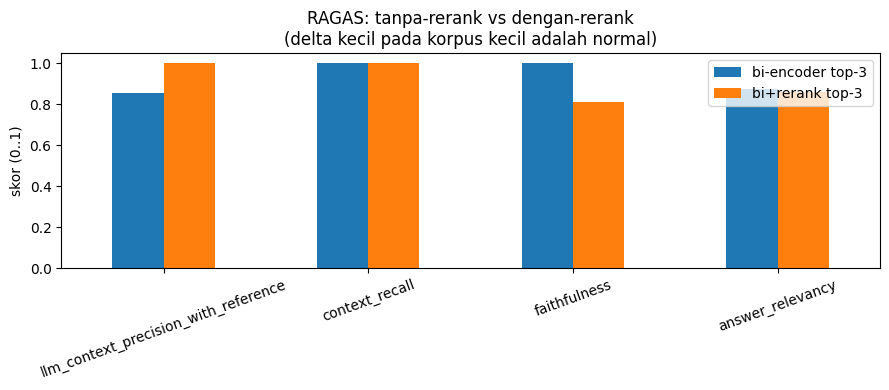

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df_A, df_B = res_A.to_pandas(), res_B.to_pandas()
print("Kolom hasil:", list(df_A.columns))

# Robust to column drift: discover metric columns dynamically
meta = {"user_input", "reference", "retrieved_contexts", "response"}
metric_cols = [c for c in df_A.columns if c not in meta]
print("NaN per metrik (A):", df_A[metric_cols].isna().sum().to_dict())
print("NaN per metrik (B):", df_B[metric_cols].isna().sum().to_dict())
# Catatan: mean() melewati NaN — makanya kita CETAK jumlah NaN dulu;
# di set ~7 baris, 1 NaN bisa menggeser rata-rata cukup signifikan.

summary = pd.DataFrame({
    "bi-encoder top-3": df_A[metric_cols].mean(),
    "bi+rerank top-3": df_B[metric_cols].mean()
})
summary["delta"] = summary["bi+rerank top-3"] - summary["bi-encoder top-3"]
summary["n_valid_A"] = df_A[metric_cols].notna().sum()   # berapa skor non-NaN (dari total pertanyaan)
summary["n_valid_B"] = df_B[metric_cols].notna().sum()
print("\nRingkasan rata-rata:")
print(summary.round(3))

summary[["bi-encoder top-3", "bi+rerank top-3"]].plot.bar(figsize=(9, 4))
plt.ylabel("skor (0..1)")
plt.title("RAGAS: tanpa-rerank vs dengan-rerank\n(delta kecil pada korpus kecil adalah normal)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Membaca hasil dengan jujur

- **Context Precision** adalah metrik yang paling relevan untuk efek reranking — ia mengukur proporsi dan posisi potongan relevan di top-k. Perhatikan delta-nya: di sinilah reranking paling mungkin terlihat menaikkan angka.
- **Selalu lihat kolom `n_valid` dulu.** Metrik dengan banyak NaN tidak bisa dipercaya rata-ratanya. Contoh nyata: `answer_relevancy` sering NaN untuk jawaban faktual yang sangat pendek (mis. "tiga bulan penuh") — RAGAS membuat metrik ini dengan cara menurunkan beberapa pertanyaan dari jawaban, dan satu kalimat pendek tak cukup untuk itu. Pelajaran: **pilih metrik yang sesuai dengan bentuk jawabanmu.**
- **Faithfulness & Context Recall** bisa bergerak naik atau turun pada set kecil (7 pertanyaan) karena varians judge dan jawaban yang di-regenerate per varian. Jangan membaca delta kecil sebagai kesimpulan kuat — gunakan triage per-pertanyaan di bawah untuk memahami *kenapa*.
- Intinya: satu angka rata-rata tidak pernah cukup. Baca `n_valid`, baca per pertanyaan, dan pahami metrik mana yang cocok untuk tugasmu.

In [9]:
# Worst-question triage: find which question benefited most from reranking
m = pd.merge(df_A, df_B, on="user_input", suffixes=("_A", "_B"))

# Find precision column (name may vary across RAGAS versions)
prec_cols = [c for c in df_A.columns if "precision" in c.lower()]
if prec_cols:
    pc = prec_cols[0]
    m["delta_precision"] = m[f"{pc}_B"] - m[f"{pc}_A"]
    best = m.sort_values("delta_precision", ascending=False).iloc[0]
    print("Pertanyaan yang paling terbantu rerank:", best["user_input"])
    qi = questions.index(best["user_input"])
    print("Konteks tanpa-rerank:", retrieve(best["user_input"], False))
    print("Konteks dengan-rerank:", retrieve(best["user_input"], True))
else:
    print("Kolom precision tidak ditemukan; cek metric_cols di atas:", metric_cols)

# Row with lowest Faithfulness in variant B
fcols = [c for c in df_B.columns if "faith" in c.lower()]
if fcols:
    worst = df_B.sort_values(fcols[0]).iloc[0]
    print("\nFaithfulness terendah:", worst["user_input"], "->", worst["response"][:160])
else:
    print("\nKolom faithfulness tidak ditemukan; cek metric_cols di atas:", metric_cols)

Pertanyaan yang paling terbantu rerank: Berapa hari cuti tahunan yang didapat pegawai tetap?
Konteks tanpa-rerank: ['Pengajuan cuti tahunan dilakukan melalui portal HR minimal tiga hari kerja sebelum tanggal cuti.', 'Setiap pegawai tetap memperoleh jatah dua belas hari libur berbayar per tahun kalender.', 'Gaji dibayarkan pada tanggal 25 setiap bulan; jika tanggal 25 jatuh pada hari libur maka dibayarkan pada hari kerja sebelumnya.']
Konteks dengan-rerank: ['Setiap pegawai tetap memperoleh jatah dua belas hari libur berbayar per tahun kalender.', 'Pengajuan cuti tahunan dilakukan melalui portal HR minimal tiga hari kerja sebelum tanggal cuti.', 'Cuti sakit diberikan maksimal sepuluh hari per tahun; sakit lebih dari dua hari berturut-turut wajib melampirkan surat keterangan dokter.']

Faithfulness terendah: Berapa hari cuti tahunan yang didapat pegawai tetap? -> 21 hari libur berbayar per tahun kalender.


## Triage: di mana rerank paling menolong (dan di mana RAG masih lemah)

Sel ini mencari pertanyaan yang **paling terbantu** reranking (delta Context Precision tertinggi) lalu menampilkan konteksnya tanpa-rerank vs dengan-rerank, serta baris dengan **Faithfulness terendah** (kandidat halusinasi).

## Caveat: Bias Judge + Keterbatasan Eksperimen

### Self-preference bias

LLM-judge diketahui cenderung menyukai jawaban yang *segaya atau sekeluarga* dengan dirinya.  
Karena judge kita (**Llama-3.1** via NIM) **berbeda keluarga** dari generator (**Qwen**), kita menghindari bentuk terburuk self-preference bias — berbeda dengan skenario di mana Qwen menilai jawaban Qwen sendiri.

### Keterbatasan lain yang perlu diingat

| Keterbatasan | Dampak |
|---|---|
| Set tes kecil (~7 pertanyaan) | Rata-rata sangat berisik; 1 NaN bisa menggeser hasil signifikan |
| Judge juga LLM | Bisa salah-parse respons → menghasilkan NaN atau skor aneh |
| Rate limit free-tier NIM | Error 429 mungkin terjadi → kurangi `max_workers` atau tambah delay |
| Korpus & pertanyaan spesifik | Hasil tidak dapat langsung digeneralisasi ke domain lain |

> **RAGAS adalah kompas, bukan vonis.**  
> Gunakan sebagai sinyal relatif (A vs B), bukan angka absolut yang sakral.

## Ringkasan + Jembatan ke nb05

### Apa yang sudah kita capai?

| Notebook | Apa yang dilakukan |
|---|---|
| **nb03** | *Menunjukkan* secara visual bahwa reranker mendorong passage relevan ke atas |
| **nb04 (ini)** | *Membuktikan* dengan angka RAGAS — idealnya **Context Precision naik *atau setidaknya tidak turun*** setelah rerank; pada korpus kecil seperti ini, delta kecil adalah hasil yang valid. |

> **Catatan delta kecil:** Pada korpus kecil (12 passage, 7 pertanyaan), bi-encoder sering sudah menaruh passage yang benar di posisi teratas, jadi delta Context Precision bisa ~0 atau sedikit negatif karena varians judge. Ini BUKAN kegagalan — justru bukti bi-encoder kita sudah kuat untuk kasus ini. Efek reranking paling terlihat pada korpus besar dengan banyak passage yang berbagi kata kunci.

### Apa yang belum sempurna?

Index kita masih pakai **L2 distance** (`IndexFlatL2`) dan **hanya ada di RAM** — tidak disimpan ke disk.

**nb05 (Scale the Index)** akan memperbaiki dua hal itu:
1. Ganti ke **cosine similarity** (`IndexFlatIP` + normalize vektor)
2. Tambah **persistence** — `faiss.write_index` / `faiss.read_index` dan ChromaDB

### PR Opsional (Eksperimen Lanjutan)

- Ganti judge ke **Gemini 2.5 Flash** (gratis, [aistudio.google.com](https://aistudio.google.com/apikey)), lihat apakah skor bergeser — ini mendemonstrasikan **varians antar judge**.
- Tambah pertanyaan tes agar rata-rata lebih stabil.
- Uji dengan `raise_exceptions=True` untuk debug NaN.